# B2 — AnoExpress cross-study context for ABCs (An. gambiae focus)

Meta-analysis context for the ABC transporters that are DE in Bouaké gambiae: are these also up across the wider Anopheles resistance literature, or Bouaké-novel?

In [28]:
import os
import numpy as np
import pandas as pd
import plotly.express as px
import plotly.graph_objects as go
import anoexpress as ae

os.makedirs("results/abc_obp", exist_ok=True)
os.makedirs("figures_ms", exist_ok=True)

# Reload Bouaké DE ABC hits from B1
abc_gam = pd.read_csv("results/abc_obp/bouake_de_abc_gambiae.csv")
print("Bouaké DE ABCs (gambiae):", abc_gam.shape)
abc_gam_sig = abc_gam[abc_gam["padj"] < 0.05].copy()
print("  significant (padj<0.05):", len(abc_gam_sig))

Bouaké DE ABCs (gambiae): (99, 16)
  significant (padj<0.05): 35


In [33]:
# AnoExpress: load fold-change matrix and rank ABCs by cross-study median FC
# analysis options: 'gamb_colu' | 'gamb_colu_arab' (+ arabiensis) | 'gamb_colu_arab_fun' (+ funestus).
# Use 'gamb_colu' — 11288 genes × 18 studies. Adding arabiensis (->8651 genes) or funestus (->8599)
# requires strict 1:1 orthology and drops Anopheles-specific genes including ABCC9 and ABCC11.
fc = ae.data(data_type="fcs", analysis="gamb_colu")
print("fc matrix shape:", fc.shape)
print("fc columns (studies):", list(fc.columns)[:5], "... total", len(fc.columns))
print("sample index:", list(fc.index)[:5])
fc.head(3)

fc matrix shape: (11288, 18)
fc columns (studies): ['Tiefora_v_Ngousso', 'Ban_v_BanS', 'BanRe_v_BanS', 'Bak_v_Kisumu', 'VK7_v_Kisumu'] ... total 18
sample index: ['AGAP007364', 'AGAP010071', 'AGAP007774', 'AGAP006191', 'AGAP005809']


,Tiefora_v_Ngousso,Ban_v_BanS,BanRe_v_BanS,Bak_v_Kisumu,VK7_v_Kisumu,Cameroon_v_Ngousso,Chad_v_Ngousso,Niger_v_Ngousso,Nigeria_v_Ngousso,Agboville_v_Mali,Agboville_v_Ngousso,Dabou_v_Mali,Dabou_v_Ngousso,Tiassale_v_Mali,Tiassale_v_Ngousso,Bouake_gamb_unexp_v_Kisumu,Bouake_colu_unexp_v_Ngousso,BusiaSurvivors_v_Kisumu
GeneID,,,,,,,,,,,,,,,,,,
AGAP007364,-2.62,-1.02,1.33,0.41,0.89,-1.04,0.12,-1.44,-1.00,-0.53,-2.29,-1.02,-2.80,-2.29,-4.05,-0.90,-2.01,1.47
AGAP010071,-2.34,-2.31,-0.36,-0.37,-0.59,-1.87,-1.82,-1.67,-1.71,-0.51,-2.19,-0.28,-1.98,-0.26,-1.95,0.14,-2.45,-0.04
AGAP007774,-1.78,-0.93,-0.19,-0.17,-0.47,-0.12,-0.06,-0.12,-0.11,-0.12,-1.38,-0.23,-1.50,-0.38,-1.64,-0.29,-1.25,1.30


In [34]:
# Exclude Bouaké columns from the cross-study median (avoid circularity with this study)
bouake_cols = [c for c in fc.columns if "Bouake" in c]
other_cols = [c for c in fc.columns if c not in bouake_cols]
print("excluded:", bouake_cols)
print("other studies:", len(other_cols))

# Per-gene summary across the meta-analysis
meta = pd.DataFrame({
    "median_fc": fc[other_cols].median(axis=1),
    "mean_fc":   fc[other_cols].mean(axis=1),
    "n_up_p05":  (fc[other_cols] > 0).sum(axis=1),   # up = FC>0 (log2)
    "n_dn_p05":  (fc[other_cols] < 0).sum(axis=1),
    "n_studies": fc[other_cols].notna().sum(axis=1),
}).reset_index().rename(columns={"index":"GeneID","GeneID":"GeneID"})

# keep both Bouaké columns
meta["bouake_gamb_unexp"] = fc["Bouake_gamb_unexp_v_Kisumu"].values
meta["bouake_colu_unexp"] = fc["Bouake_colu_unexp_v_Ngousso"].values
meta.head(3)

excluded: ['Bouake_gamb_unexp_v_Kisumu', 'Bouake_colu_unexp_v_Ngousso']
other studies: 16


,GeneID,median_fc,mean_fc,n_up_p05,n_dn_p05,n_studies,bouake_gamb_unexp,bouake_colu_unexp
0,AGAP007364,-1.02,-0.992500,5,11,16,-0.90,-2.01
1,AGAP010071,-1.69,-1.265625,0,16,16,0.14,-2.45
2,AGAP007774,-0.21,-0.493750,1,15,16,-0.29,-1.25


In [35]:
# Cross-reference Bouaké DE ABCs with meta-analysis context
abc_merge = abc_gam.merge(meta, on="GeneID", how="left")

# Flag each gene
abc_merge["in_meta"] = abc_merge["median_fc"].notna()
abc_merge["meta_up_consistent"] = abc_merge["median_fc"] > 0.5
abc_merge["bouake_sig_up"] = (abc_merge["padj"] < 0.05) & (abc_merge["log2FoldChange"] > 0)

def classify(row):
    if not row["in_meta"]:
        return "not in AnoExpress"
    if row["bouake_sig_up"] and row["meta_up_consistent"]:
        return "shared candidate (Bouaké + meta up)"
    if row["bouake_sig_up"] and not row["meta_up_consistent"]:
        return "Bouaké novel (up here, flat/down in meta)"
    if not row["bouake_sig_up"] and row["meta_up_consistent"]:
        return "meta-only (not sig in Bouaké)"
    return "neither"

abc_merge["class"] = abc_merge.apply(classify, axis=1)
print(abc_merge["class"].value_counts())

# Save
out_cols = ["GeneID","GeneName","log2FoldChange","padj","pfam_domains",
            "median_fc","mean_fc","n_up_p05","n_dn_p05","n_studies",
            "bouake_gamb_unexp","bouake_colu_unexp","class"]
abc_merge[out_cols].to_csv("results/abc_obp/bouake_abc_gambiae_vs_anoexpress.csv", index=False)
abc_merge[abc_merge["bouake_sig_up"]][out_cols].sort_values("log2FoldChange", ascending=False).head(15)

class
neither                                      55
Bouaké novel (up here, flat/down in meta)    28
not in AnoExpress                             8
meta-only (not sig in Bouaké)                 7
shared candidate (Bouaké + meta up)           1
Name: count, dtype: int64


,GeneID,GeneName,log2FoldChange,padj,pfam_domains,median_fc,mean_fc,n_up_p05,n_dn_p05,n_studies,bouake_gamb_unexp,bouake_colu_unexp,class
0,AGAP008436,ABCC11,2.263626,9.891000e-07,PF00005;PF00664,-0.115,-0.268750,8.0,8.0,16.0,-1.92,-0.80,"Bouaké novel (up here, flat/down in meta)"
1,AGAP008437,ABCC9,1.902601,5.580121e-10,PF00005;PF00664,0.615,0.270000,11.0,5.0,16.0,0.07,2.41,shared candidate (Bouaké + meta up)
2,AGAP006380,ABCA2,1.837999,3.065699e-07,PF00005;PF12698,-0.130,-0.156250,5.0,11.0,16.0,0.19,2.41,"Bouaké novel (up here, flat/down in meta)"
3,AGAP012156,ABCA5,1.775297,1.492250e-05,PF00005;PF12698,-0.390,-0.801875,3.0,13.0,16.0,-1.98,-0.71,"Bouaké novel (up here, flat/down in meta)"
4,AGAP009463,ABCG11,1.491962,4.895114e-16,PF00005;PF01061,0.175,0.211250,9.0,6.0,16.0,-0.45,0.39,"Bouaké novel (up here, flat/down in meta)"
5,AGAP000390,NaN,1.432777,1.659320e-09,PF00122;PF00702;PF13246;PF16209;PF16212,-0.415,-0.211875,6.0,10.0,16.0,-0.07,1.18,"Bouaké novel (up here, flat/down in meta)"
6,AGAP027980,NaN,1.289861,1.824852e-07,PF00005;PF00664,0.365,0.298125,11.0,5.0,16.0,-0.53,0.67,"Bouaké novel (up here, flat/down in meta)"
7,AGAP002638,ABCH1,1.231517,3.939473e-14,PF00005;PF12698,0.290,0.325625,11.0,5.0,16.0,-0.81,-0.22,"Bouaké novel (up here, flat/down in meta)"
8,AGAP008539,NaN,1.015792,4.588508e-02,PF04280,-1.665,-1.645625,1.0,15.0,16.0,-1.92,0.00,"Bouaké novel (up here, flat/down in meta)"
9,AGAP009472,ABCG20,1.013553,1.905599e-13,PF00005;PF01061,-0.050,0.061250,7.0,8.0,16.0,-1.17,-0.21,"Bouaké novel (up here, flat/down in meta)"


/var/folders/yd/tz1zj4195ybgmg97z4y695w40000gp/T/ipykernel_20722/2051805569.py:54: DeprecationWarning: 
Support for Kaleido versions less than 1.0.0 is deprecated and will be removed after September 2025.
Please upgrade Kaleido to version 1.0.0 or greater (`pip install 'kaleido>=1.0.0'` or `pip install 'plotly[kaleido]'`).

  fig.write_image("figures_ms/b2_abc_bouake_vs_anoexpress.png", scale=2)


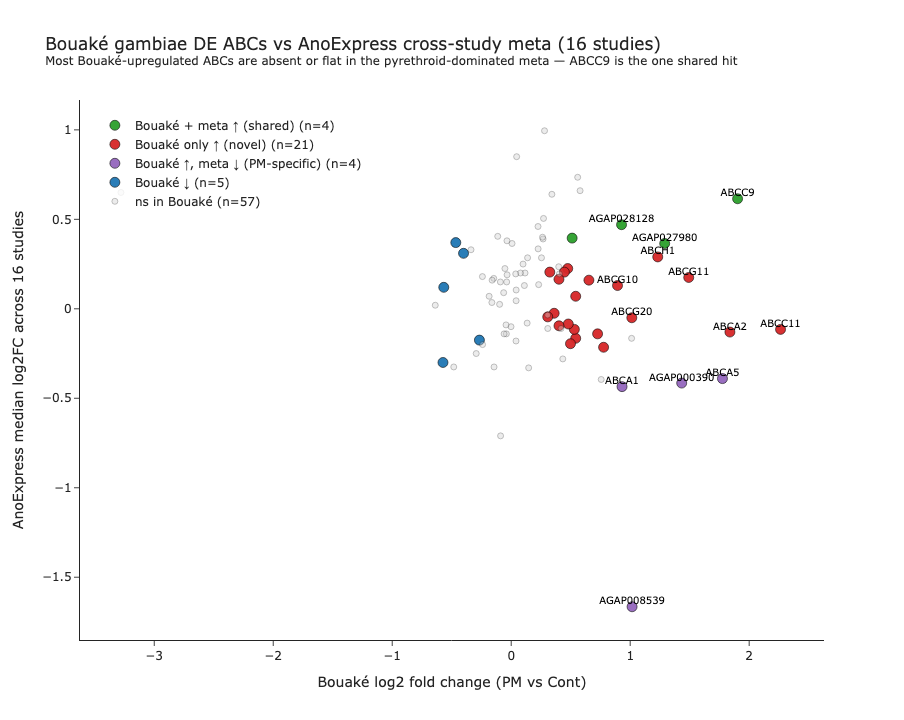

In [42]:
# Bouaké log2FC vs AnoExpress median — quadrant-classified (shared vs novel)
d = abc_joined[abc_joined["in_meta"]].copy()
d["label"] = np.where(d["GeneName"].isna(), d["GeneID"], d["GeneName"].astype(str))

def quadrant(r):
    if r["padj"] < 0.05 and r["log2FoldChange"] > 0:
        return "Bouaké + meta ↑ (shared)" if r["median_fc"] > 0.3 else (
               "Bouaké only ↑ (novel)"   if r["median_fc"] >= -0.3 else
               "Bouaké ↑, meta ↓ (PM-specific)")
    if r["padj"] < 0.05 and r["log2FoldChange"] < 0:
        return "Bouaké ↓"
    return "ns in Bouaké"
d["quadrant"] = d.apply(quadrant, axis=1)

colmap = {
    "Bouaké + meta ↑ (shared)":  "#2ca02c",
    "Bouaké only ↑ (novel)":     "#d62728",
    "Bouaké ↑, meta ↓ (PM-specific)": "#9467bd",
    "Bouaké ↓":                  "#1f77b4",
    "ns in Bouaké":              "#d0d0d0",
}

fig = go.Figure()
for k, c in colmap.items():
    s = d[d["quadrant"] == k]
    fig.add_trace(go.Scatter(
        x=s["log2FoldChange"], y=s["median_fc"], mode="markers",
        name=f"{k} (n={len(s)})",
        marker=dict(size=10 if "ns" not in k else 6, color=c,
                    opacity=0.4 if "ns" in k else 0.95,
                    line=dict(color="black", width=0.6)),
        text=s["label"],
        customdata=s[["GeneID","padj","n_up_p05","n_studies"]].values,
        hovertemplate="<b>%{text}</b><br>%{customdata[0]}<br>Bouaké log2FC: %{x:.2f} (padj %{customdata[1]:.2e})<br>Meta median FC: %{y:.2f} (%{customdata[2]}/%{customdata[3]} studies up)<extra></extra>",
    ))
# Label sig Bouaké ABCs with |log2FC| > 0.8
top = d[(d["padj"] < 0.05) & (d["log2FoldChange"].abs() > 0.8)]
fig.add_trace(go.Scatter(
    x=top["log2FoldChange"], y=top["median_fc"], mode="text",
    text=top["label"], textposition="top center",
    textfont=dict(size=10, color="black"),
    showlegend=False, hoverinfo="skip",
))
fig.add_hline(y=0, line_color="grey", line_dash="dot")
fig.add_vline(x=0, line_color="grey", line_dash="dot")
fig.update_layout(
    title="Bouaké gambiae DE ABCs vs AnoExpress cross-study meta (16 studies)<br><sup>Most Bouaké-upregulated ABCs are absent or flat in the pyrethroid-dominated meta — ABCC9 is the one shared hit</sup>",
    xaxis_title="Bouaké log2 fold change (PM vs Cont)",
    yaxis_title="AnoExpress median log2FC across 16 studies",
    template="simple_white", width=1050, height=720,
    legend=dict(x=0.02, y=0.98, bgcolor="rgba(255,255,255,0.8)"),
)
fig.write_html("figures_ms/b2_abc_bouake_vs_anoexpress.html")
fig.write_image("figures_ms/b2_abc_bouake_vs_anoexpress.png", scale=2)
fig.show()

/var/folders/yd/tz1zj4195ybgmg97z4y695w40000gp/T/ipykernel_20722/1865038591.py:48: DeprecationWarning: 
Support for Kaleido versions less than 1.0.0 is deprecated and will be removed after September 2025.
Please upgrade Kaleido to version 1.0.0 or greater (`pip install 'kaleido>=1.0.0'` or `pip install 'plotly[kaleido]'`).

  fig.write_image("figures_ms/b2_abc_strip.png", scale=2)


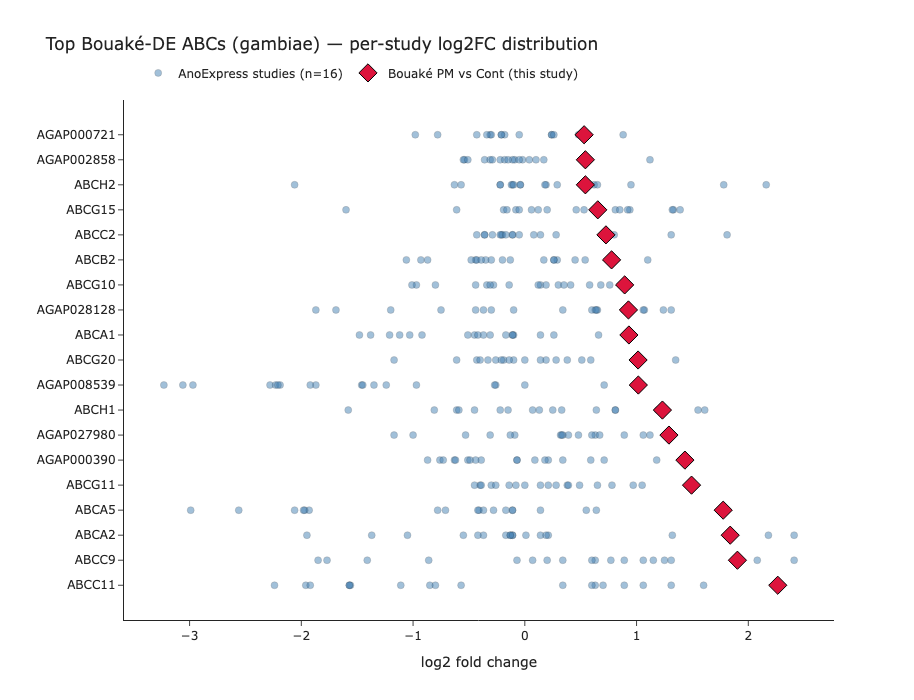

In [49]:
# Strip plot: top Bouaké-sig ABCs (y) x per-study log2FC (x) — shows study-level context
top_ids = abc_gam_sig.sort_values("log2FoldChange", ascending=False).head(20)["GeneID"].tolist()
sub = fc.loc[[g for g in top_ids if g in fc.index]].copy()
sub["GeneID"] = sub.index
long = sub.melt(id_vars="GeneID", var_name="study", value_name="log2FC")

# add Bouaké PM log2FC as extra row for comparison
bouake_pm = abc_gam_sig.set_index("GeneID").loc[[g for g in top_ids if g in sub.index], ["GeneName","log2FoldChange","padj"]]
bouake_pm = bouake_pm.reset_index().assign(study="Bouaké PM vs Cont (this study)")
bouake_pm_long = bouake_pm.rename(columns={"log2FoldChange":"log2FC"})[["GeneID","study","log2FC"]]
long2 = pd.concat([long, bouake_pm_long], ignore_index=True)

# attach gene labels
label_map = bouake_pm.set_index("GeneID")["GeneName"].to_dict()
long2["label"] = long2["GeneID"].map(lambda g: label_map.get(g) if isinstance(label_map.get(g), str) else g)
# order y by Bouaké log2FC (descending) so highest is at top
gene_order = bouake_pm.sort_values("log2FoldChange", ascending=True)["GeneID"].tolist()
long2["label"] = pd.Categorical(long2["label"], categories=[label_map.get(g) if isinstance(label_map.get(g), str) else g for g in gene_order], ordered=True)

# colour Bouaké point differently
long2["is_bouake"] = long2["study"].str.contains("Bouaké PM")

fig = go.Figure()
fig.add_trace(go.Scatter(
    x=long2.loc[~long2["is_bouake"],"log2FC"],
    y=long2.loc[~long2["is_bouake"],"label"],
    mode="markers",
    name=f"AnoExpress studies (n={len(other_cols)})",
    marker=dict(size=7, color="steelblue", opacity=0.5, line=dict(color="black",width=0.3)),
    hovertext=long2.loc[~long2["is_bouake"],"study"],
    hovertemplate="%{hovertext}<br>log2FC: %{x:.2f}<extra></extra>",
))
fig.add_trace(go.Scatter(
    x=long2.loc[long2["is_bouake"],"log2FC"],
    y=long2.loc[long2["is_bouake"],"label"],
    mode="markers",
    name="Bouaké PM vs Cont (this study)",
    marker=dict(size=14, color="crimson", symbol="diamond", line=dict(color="black",width=1)),
))
fig.add_vline(x=0, line_color="grey", line_dash="dot")
fig.update_layout(
    title="Top Bouaké-DE ABCs (gambiae) — per-study log2FC distribution",
    xaxis_title="log2 fold change", yaxis_title="",
    template="simple_white", width=1000, height=700,
    legend=dict(x=0.02, y=1.08, orientation="h"),
)
fig.write_html("figures_ms/b2_abc_strip.html")
fig.write_image("figures_ms/b2_abc_strip.png", scale=2)
fig.show()

In [38]:
# ae.load_candidates — official ABC ranking by median FC across meta-analysis
try:
    cand_abc = ae.load_candidates(
        analysis="gamb_colu",
        query_annotation="ABC_tran",
        func=np.nanmedian,
    )
    print("cand_abc shape:", cand_abc.shape)
    print(cand_abc.head(10))
except Exception as e:
    print("load_candidates error:", e)
    cand_abc = None

cand_abc shape: (50, 5)
       GeneID GeneName                                    GeneDescription  \
0  AGAP008945    ABCG6  ATP-binding cassette transporter (ABC transpor...   
1  AGAP003221    ABCC3  ATP-binding cassette transporter (ABC transpor...   
2  AGAP008437    ABCC9  ATP-binding cassette transporter (ABC transpor...   
3  AGAP028128      NaN                                                NaN   
4  AGAP002051   ABCG14  ATP-binding cassette transporter (ABC transpor...   
5  AGAP004603    ABCG4  ATP-binding cassette transporter (ABC transpor...   
6  AGAP027980      NaN                                                NaN   
7  AGAP002060    ABCH3  ATP-binding cassette transporter (ABC transpor...   
8  AGAP009468   ABCG17  ATP-binding cassette transporter (ABC transpor...   
9  AGAP008889   ABCG15  ATP-binding cassette transporter (ABC transpor...   

   median log2 Fold Change  median Fold Change  
0                    0.930                1.91  
1                    0.850    

In [39]:
# Merge AnoExpress ABC candidate ranking with Bouaké DE to flag overlap
cand_abc_renamed = cand_abc.rename(columns={
    "median log2 Fold Change": "ae_median_log2FC",
    "median Fold Change": "ae_median_FC",
})[["GeneID","ae_median_log2FC","ae_median_FC"]]

abc_joined = abc_merge.merge(cand_abc_renamed, on="GeneID", how="left")
abc_joined["in_ae_candidates"] = abc_joined["ae_median_log2FC"].notna()
abc_joined["shared_hit"] = (abc_joined["padj"] < 0.05) & (abc_joined["log2FoldChange"] > 0) & (abc_joined["in_ae_candidates"])

print("Bouaké sig-up ABCs that are also AnoExpress candidates:")
shared = abc_joined[abc_joined["shared_hit"]].sort_values("log2FoldChange", ascending=False)
print(shared[["GeneID","GeneName","log2FoldChange","padj","ae_median_log2FC"]].to_string(index=False))

# Final annotated table
final_cols = ["GeneID","GeneName","log2FoldChange","padj","pfam_domains",
              "median_fc","n_up_p05","n_studies",
              "ae_median_log2FC","in_ae_candidates","shared_hit","class"]
abc_joined[final_cols].to_csv("results/abc_obp/bouake_abc_gambiae_vs_anoexpress.csv", index=False)
print("\nClass counts (Bouaké DE ABCs):")
print(abc_joined["class"].value_counts())

Bouaké sig-up ABCs that are also AnoExpress candidates:
    GeneID GeneName  log2FoldChange         padj  ae_median_log2FC
AGAP008436   ABCC11        2.263626 9.891000e-07            -0.685
AGAP008437    ABCC9        1.902601 5.580121e-10             0.615
AGAP006380    ABCA2        1.837999 3.065699e-07            -0.120
AGAP012156    ABCA5        1.775297 1.492250e-05            -0.415
AGAP009463   ABCG11        1.491962 4.895114e-16             0.175
AGAP027980      NaN        1.289861 1.824852e-07             0.365
AGAP002638    ABCH1        1.231517 3.939473e-14             0.190
AGAP009472   ABCG20        1.013553 1.905599e-13            -0.120
AGAP006379    ABCA1        0.931474 2.091206e-04            -0.395
AGAP028128      NaN        0.927320 7.671050e-04             0.470
AGAP009464   ABCG10        0.893447 2.357839e-07             0.130
AGAP005639    ABCB2        0.776401 2.569427e-05            -0.250
AGAP001775    ABCC2        0.725983 6.674270e-05            -0.110
AGAP00

In [41]:
# Summary for B2
print("=== Phase B2 summary ===")
print(f"Total ABC genes in Bouaké DE: {len(abc_gam)}")
print(f"Significantly upregulated (padj<0.05): {int(abc_joined['bouake_sig_up'].sum())}")
print(f"Cross-study classes:")
print(abc_joined["class"].value_counts().to_string())
print()
print("Shared candidates (up in Bouaké AND median log2FC > 0.5 across 16 other AnoExpress studies):")
shared = abc_joined[(abc_joined["bouake_sig_up"]) & (abc_joined["meta_up_consistent"])]
print(shared[["GeneID","GeneName","log2FoldChange","padj","median_fc","n_up_p05","n_studies"]].to_string(index=False))
print()
print("Top AnoExpress ABC candidates that are NOT significant in Bouaké gambiae:")
ae_only = abc_joined[(abc_joined["in_ae_candidates"]) & (abc_joined["ae_median_log2FC"] > 0.3) & ~(abc_joined["bouake_sig_up"])]
print(ae_only[["GeneID","GeneName","log2FoldChange","padj","ae_median_log2FC"]].sort_values("ae_median_log2FC", ascending=False).head(10).to_string(index=False))

=== Phase B2 summary ===
Total ABC genes in Bouaké DE: 99
Significantly upregulated (padj<0.05): 30
Cross-study classes:
class
neither                                      55
Bouaké novel (up here, flat/down in meta)    28
not in AnoExpress                             8
meta-only (not sig in Bouaké)                 7
shared candidate (Bouaké + meta up)           1

Shared candidates (up in Bouaké AND median log2FC > 0.5 across 16 other AnoExpress studies):
    GeneID GeneName  log2FoldChange         padj  median_fc  n_up_p05  n_studies
AGAP008437    ABCC9        1.902601 5.580121e-10      0.615      11.0       16.0

Top AnoExpress ABC candidates that are NOT significant in Bouaké gambiae:
    GeneID GeneName  log2FoldChange     padj  ae_median_log2FC
AGAP008945    ABCG6       -3.279888 0.052690             0.930
AGAP003221    ABCC3        0.045688 0.869787             0.850
AGAP002051   ABCG14       -0.465667 0.007940             0.370
AGAP004603    ABCG4       -0.035713 0.928776      